# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("delivery_dataset.csv")
df

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [10]:
X_train = df[["Расстояние до клиента (в км)", "Количество позиций в чеке (в шт.)", "Балл пробок на дорогах (в баллах)", "Погода (в градусах Цельсия)", "Этаж доставки (в этажах)"]][:300]
X_test = df[["Расстояние до клиента (в км)", "Количество позиций в чеке (в шт.)", "Балл пробок на дорогах (в баллах)", "Погода (в градусах Цельсия)", "Этаж доставки (в этажах)"]][400:500]
X_val = df[["Расстояние до клиента (в км)", "Количество позиций в чеке (в шт.)", "Балл пробок на дорогах (в баллах)", "Погода (в градусах Цельсия)", "Этаж доставки (в этажах)"]][300:400]

y_train = df[["Время доставки (в минутах)"]][:300].to_numpy(dtype=float).ravel()
y_val   = df[["Время доставки (в минутах)"]][300:400].to_numpy(dtype=float).ravel()
y_test  = df[["Время доставки (в минутах)"]][400:500].to_numpy(dtype=float).ravel()

#### Вопрос 1.

**Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?**

Мы разбиваем выборку, чтобы обучить модель, а не просто попросить ее запомнить весь датасет:
1. тренировочная выборка необходима для непосредственного обучения модели
2. валидационная выборка нужна для промежуточной оценки работы модели и настройки параметров внутри
3. тестовая же используется для непосредственного теста того, как хороша обучилась моделька

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [11]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.0
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'sparse_cg'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 's

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

X_train_b = np.c_[np.ones(300), X_train]
X_val_b = np.c_[np.ones(100), X_val]

history = {
    "sse_train": [], "sse_val": [],
    "mse_train": [], "mse_val": [],
    "rmse_train": [], "rmse_val": [],
}

def record(w):
    sse_tr, mse_tr, rmse_tr = errors(X_train_b, y_train, w)
    sse_va, mse_va, rmse_va = errors(X_val_b, y_val, w)
    history["sse_train"].append(sse_tr);  history["sse_val"].append(sse_va)
    history["mse_train"].append(mse_tr);  history["mse_val"].append(mse_va)
    history["rmse_train"].append(rmse_tr);history["rmse_val"].append(rmse_va)

def errors(X, y, w):
    resid = y - X @ w
    sse = float(resid @ resid)
    mse = sse / len(y)
    rmse = np.sqrt(mse)
    return sse, mse, rmse

alpha = 0.0
max_iter = 100
epsilon = 1e-8
n_features = X_train_b.shape[1]
A = X_train_b.T @ X_train_b
b = X_train_b.T @ y_train
w = np.zeros(n_features)
r = b - A @ w
p = r.copy()
rs_old = r @ r

for it in range(1, max_iter + 1):
    Ap = A @ p
    step = rs_old / float(p @ Ap)
    w = w + step * p
    r = r - step * Ap
    record(w)
    rs_new = float(r @ r)
    if np.sqrt(rs_new) < epsilon:
        print(f"Остановка на итерации {it}: ||r|| = {np.sqrt(rs_new):.2e}")
        break
    p = r + (rs_new / rs_old) * p
    rs_old = rs_new

Остановка на итерации 7: ||r|| = 2.01e-09


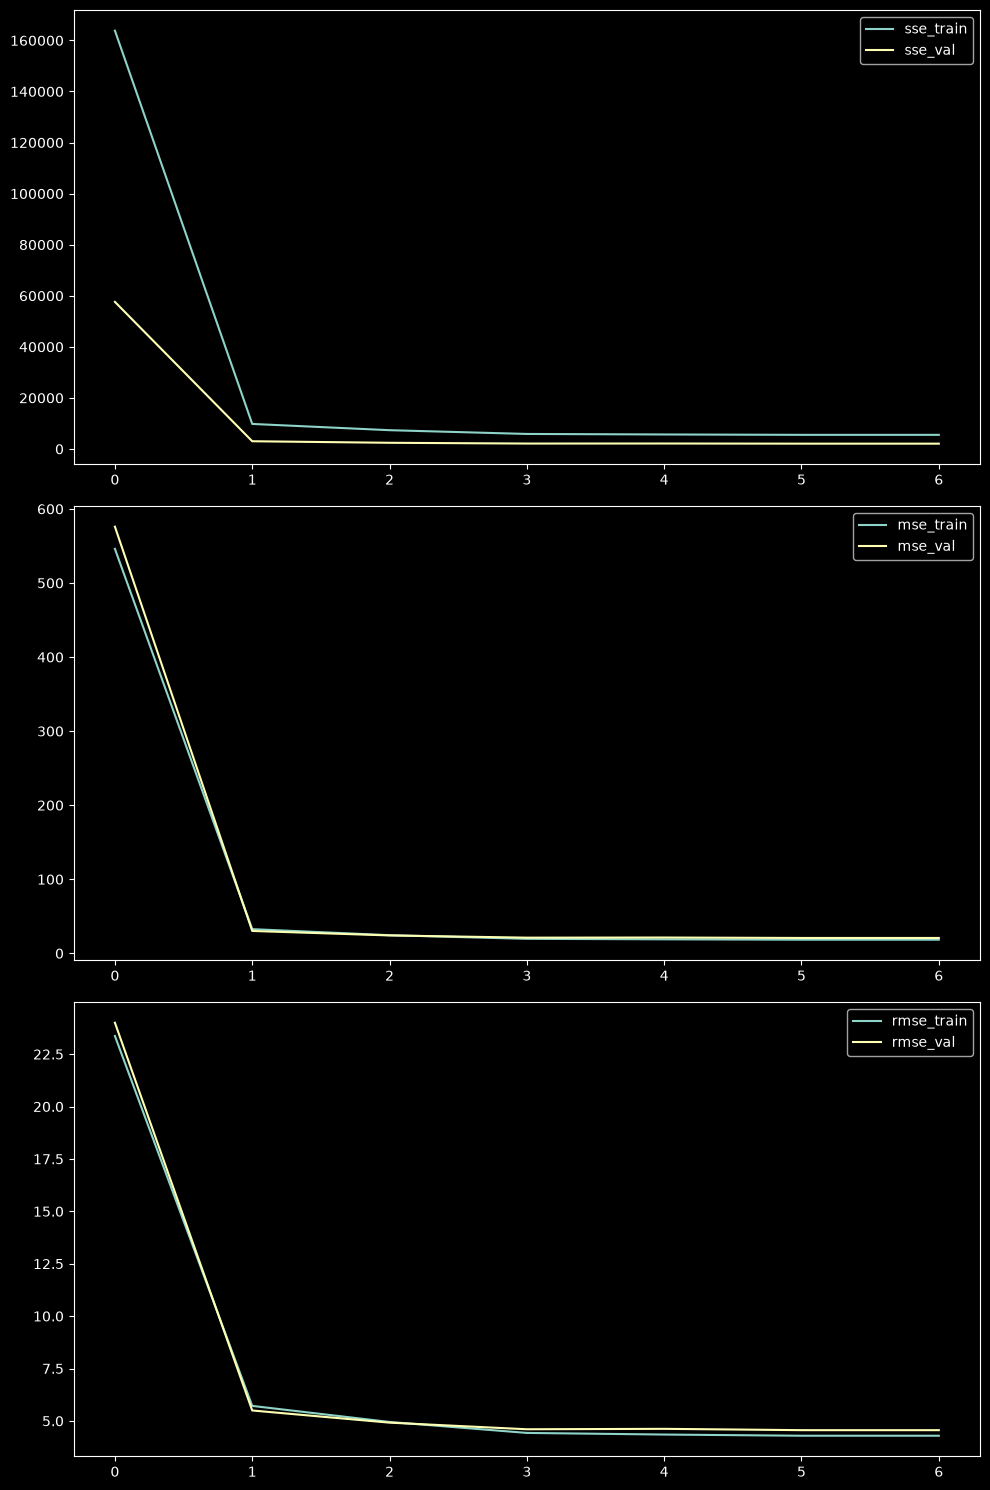

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
axes[0].plot(history["sse_train"], label="sse_train")
axes[0].plot(history["sse_val"], label="sse_val")
axes[0].legend()

axes[1].plot(history["mse_train"], label="mse_train")
axes[1].plot(history["mse_val"], label="mse_val")
axes[1].legend()

axes[2].plot(history["rmse_train"], label="rmse_train")
axes[2].plot(history["rmse_val"], label="rmse_val")
axes[2].legend()

plt.tight_layout()
plt.show()

#### Вопрос 2.

**Какую информацию про нашу модель несут эти графики?**

Насколько хорошо обучается модель, а также по ней можно определить, пере(недо)обучена ли модель

#### Вопрос 3.

**Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?**

Оба графика просто идут вниз, но не образуют почти горизонтальную линию (нет стабилизации) или просто останавливаются на высоком уровне ошибок

**Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?**

Обе линии идут вниз и в какой-то момент стабилизируются (либо просто падают ближе к 0), при этом график train чуть ниже чем val (не касается sse, так как там еще размерность имеет значение)

**Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?**

График train сильно падает, сводя ошибку к 0, а val сначала падает, а потом после стабилизации начинает расти наверх или иметь менее предсказуемое поведение

#### Шаг 6. Применение модели на тестовой выборке

In [ ]:
model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### Шаг 7. RMSE на тестовой выборке

In [ ]:
from sklearn.metrics import mean_squared_error
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print(mse)

#### Вопрос 4.

**Что получившийся RMSE может сказать о нашей модели?**

RMSE показывает насколько квадратично средне ошибается модель, в нашем случае это 5 минут, то есть в целом модель ошибается на +- 5 минут